# Polynomial Regresion
> 1 input | 1 target

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
# data generation
# of Polynomial with degree 2
x = 5 * np.random.rand(300,1) - 5
# y = x^2 + 6x + 8
y = (x**2) + (6*x) + 8 + np.random.rand(300,1)


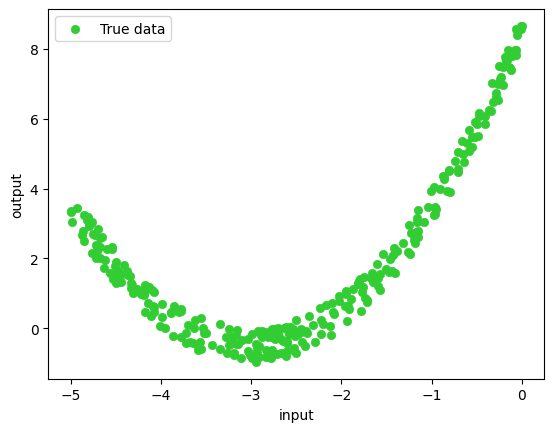

In [21]:
plt.scatter(x,y,color = 'limegreen', label = 'True data', lw = 0.5)
plt.xlabel('input')
plt.ylabel('output')
plt.legend()
plt.show()

In [20]:
# LinearRegression for comaparison
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.2, random_state=2)

lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
print('Intercept: ',lr.intercept_)
print('Coefficient: ',lr.coef_)
print('R2_score = ',r2_score(y_test, y_pred_lr))

Intercept:  [5.38152501]
Coefficient:  [[1.41981229]]
R2_score =  0.2816622315563424


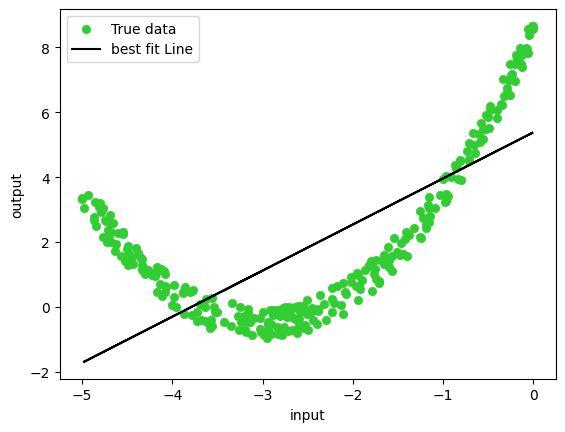

In [22]:
plt.scatter(x,y,color = 'limegreen', label = 'True data', lw = 0.5)
plt.plot(x_test, y_pred_lr, color = 'k', label = 'best fit Line')
plt.xlabel('input')
plt.ylabel('output')
plt.legend()
plt.show()

## Polynomial features

In [25]:
# here bias is x^0
# x^0, x^1, x^2
poly = PolynomialFeatures(degree = 2, include_bias=True)
x_train_trans = poly.fit_transform(x_train)     # train and transform
x_test_trans = poly.transform(x_test)       # # just transform

print(x_train[0])        # x^1
print(x_train_trans[0])  # x^0, x^1, x^2
# new dataset row

[-2.67208159]
[ 1.         -2.67208159  7.14002001]


In [26]:
# Train model with polynomial features

lr2 = LinearRegression()
lr2.fit(x_train_trans, y_train)
y_pred_poly = lr2.predict(x_test_trans)
print('Intercept: ',lr2.intercept_)
print('Coefficient: ',lr2.coef_)
print('R2_score = ',r2_score(y_test, y_pred_poly))

Intercept:  [8.50343593]
Coefficient:  [[0.         5.91412063 0.98157953]]
R2_score =  0.9857981269054531


In [30]:
# the polynomial curve parameters
x_new = np.linspace(-5,0,300).reshape(300,1)
x_new_poly = poly.transform(x_new)
y_new = lr2.predict(x_new_poly)

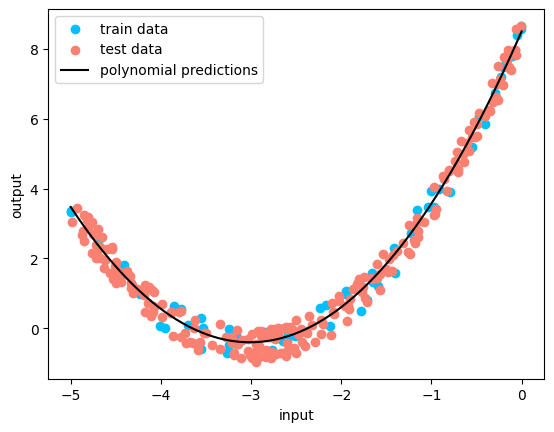

In [33]:
plt.scatter(x_train, y_train, color = 'deepskyblue', label = 'train data')
plt.scatter(x_test, y_test, color = 'salmon', label = 'test data')
plt.plot(x_new, y_new, color = 'k', label = 'polynomial predictions')
plt.xlabel('input')
plt.legend()
plt.ylabel('output')
plt.show()